In [1]:
# Data manipulation and math
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Load the dataset
df = pd.read_excel("data1.xlsx")

# Display the first 5 rows
print("Dataset Head:")
print(df.head())

# Check for any missing values and verify data types
print("\nDataset Info:")
df.info()

Dataset Head:
   Feature_1  Feature_2  Target_Class
0   0.893586  -0.351167             0
1   0.621767   0.808279             0
2  -0.232287   0.836077             0
3  -0.428056  -0.115387             1
4  -0.155135   0.531316             1

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Feature_1     200 non-null    float64
 1   Feature_2     200 non-null    float64
 2   Target_Class  200 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.8 KB


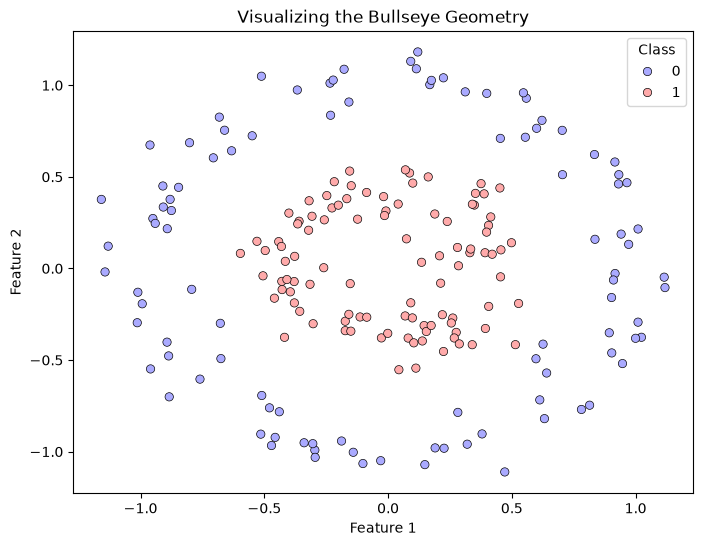

In [3]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Feature_1', y='Feature_2', hue='Target_Class', palette='bwr', edgecolor='k')

plt.title("Visualizing the Bullseye Geometry")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Class")
plt.show()

In [4]:
# Separate features (X) and target (y)
X = df[['Feature_1', 'Feature_2']]
y = df['Target_Class']

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (160, 2)
Testing data shape: (40, 2)


In [5]:
# Initialize and train a Linear SVM
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = linear_svm.predict(X_test)

# Calculate accuracy
linear_accuracy = accuracy_score(y_test, y_pred_linear)
print(f"Linear SVM Accuracy: {linear_accuracy * 100:.2f}%")

Linear SVM Accuracy: 60.00%


In [6]:
# Import the automation tool from our machine learning toolbox
from sklearn.model_selection import GridSearchCV

# 1. Create a "menu" of options for the computer to try. 
# We tell it to test degrees 2, 3, 4, and 5.
options_to_test = {'degree': [2, 3, 4, 5]}

# 2. Set up a basic, empty Polynomial SVM model for it to use as a template.
base_svm = SVC(kernel='poly')

# 3. Build the automated testing machine. 
# cv=5 means "Cross-Validation = 5". It will double-check its math 5 times for every degree just to be absolutely sure it didn't get lucky.
auto_tester = GridSearchCV(estimator=base_svm, param_grid=options_to_test, cv=5)

# 4. Press start! The machine will now rapidly build, train, and grade models for all 4 degrees on your training data.
auto_tester.fit(X_train, y_train)


# --- The Results ---

# Ask the machine which option mathematically won the tournament.
# (Because our data is circular, this will print out {'degree': 2})
print(f"The mathematical winner is: {auto_tester.best_params_}\n")

# Grab the winning model out of the machine.
best_model = auto_tester.best_estimator_

# Hand the final exam (X_test) to the winning model.
y_pred_best = best_model.predict(X_test)

# Grade the final exam.
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Winning Model Accuracy: {best_accuracy * 100:.2f}%")

# Print the detailed breakdown for the winner.
print("\nClassification Report for the Winner:")
print(classification_report(y_test, y_pred_best))

The mathematical winner is: {'degree': 2}

Winning Model Accuracy: 100.00%

Classification Report for the Winner:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        18

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [7]:
# Initialize and train an RBF SVM
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale') 
rbf_svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rbf = rbf_svm.predict(X_test)

# Calculate accuracy
rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
print(f"RBF SVM Accuracy: {rbf_accuracy * 100:.2f}%")

# Detailed breakdown of the math
print("\nRBF Classification Report:")
print(classification_report(y_test, y_pred_rbf))

RBF SVM Accuracy: 100.00%

RBF Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        18

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


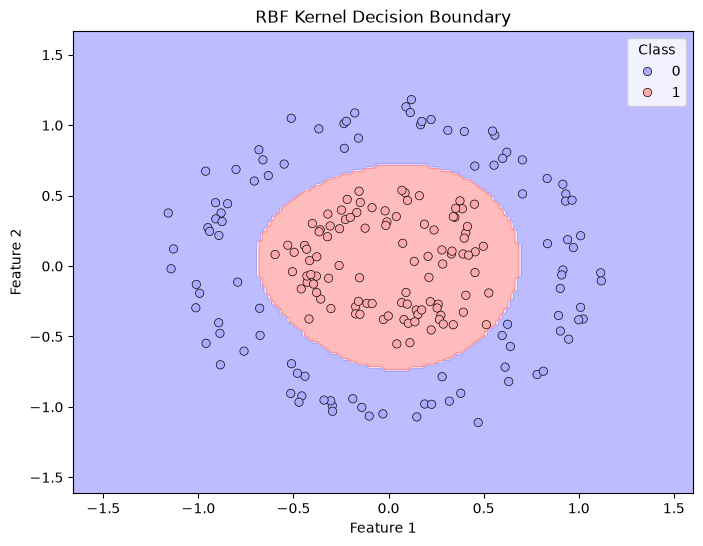

In [8]:
h = .02  # Step size in the mesh
x_min, x_max = X['Feature_1'].min() - 0.5, X['Feature_1'].max() + 0.5
y_min, y_max = X['Feature_2'].min() - 0.5, X['Feature_2'].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict the entire grid using the RBF model
Z = rbf_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the background boundary and the original data points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
sns.scatterplot(data=df, x='Feature_1', y='Feature_2', hue='Target_Class', palette='bwr', edgecolor='k')

plt.title("RBF Kernel Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Class")
plt.show()